# Equality Classifier

**Three categories:** `PRO_EQUALITY` | `ANTI_EQUALITY` | `NEUTRAL`  
**Four inequality dimensions:** income/wealth · gender · education · health  
**Three free models:** Groq (Llama-3.3-70B) · Gemini Flash 2.0 Lite · OpenRouter (Llama-3.3-70B:free)  
**Optimised for Google Colab + 500 k texts** — async requests, parquet checkpoints, resume-safe.

---
## A — Setup

In [ ]:
!pip install google-generativeai openai aiohttp pandas numpy scipy matplotlib seaborn tqdm pyarrow nest_asyncio scikit-learn --quiet

In [ ]:
import os, json, re, time, math, hashlib, asyncio, html, unicodedata
from pathlib import Path
from collections import Counter
import nest_asyncio; nest_asyncio.apply()
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import aiohttp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import warnings; warnings.filterwarnings('ignore')

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Pandas {pd.__version__} | Colab={IN_COLAB} | Async ready')


Pandas 2.2.2 | Colab=True | Async ready


In [ ]:
from google.colab import userdata

In [ ]:
# ── API keys ─────────────────────────────────
GROQ_API_KEY       = userdata.get('API1')
OPENROUTER_API_KEY = userdata.get('API2')
GEMINI_API_KEY     = userdata.get('API3')

# ── Models ───────────────────────────────────
GROQ_MODEL = 'llama-3.1-8b-instant'
GEMINI_MODEL = 'gemini-2.0-flash-lite'
OR_MODEL     = 'meta-llama/llama-3.3-70b-instruct:free'
QWEN_MODEL   = 'qwen/qwen3-235b-a22b:free'

# ── Paths  ─────────────────────────────────
INPUT_PATH     = '/content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/2. Dimensions/Results/Treashold/AllDimensions.csv'
CKPT_DIR   = '/content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/3. Narratives/All Dimensions/'
PRIMARY_CKPT   = CKPT_DIR + 'primary.parquet'
CROSSVAL_PATH  = CKPT_DIR + 'crossval.parquet'
FINAL_PATH     = CKPT_DIR + 'results_final.parquet'

# ── Classification ───────────────────────────────────────────────────────
CATEGORIES     = ['PRO_EQUALITY', 'ANTI_EQUALITY', 'NEUTRAL']
BATCH_SIZE     = 20      # texts per API call
MAX_CHARS      = 400    # truncate longer text
SAVE_EVERY     = 1000   # checkpoint every N texts
MAX_CONCURRENT = 2      # async workers (stay within 30 req/min Groq limit)
SLEEP_GROQ     = 3     # seconds between batch-groups (30 req/min → 2s gap)
SLEEP_GEMINI   = 1.5
SLEEP_OR       = 2.0     # OpenRouter free tier is slower

# ── Cross-validation ─────────────────────────────────────────────────────
N_PER_CAT = 750          # sample size per category for cross-val

print('Config OK')


Config OK


In [1]:
# Mount Google Drive
if IN_COLAB:
    drive.mount('/content/drive')

Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)
print('Directories ready:', CKPT_DIR)


NameError: name 'IN_COLAB' is not defined

---
## B — Data Preparation

In [ ]:
# Load raw dataset
print('Loading dataset...')
df = pd.read_csv(INPUT_PATH)
df['id'] = df['id'].astype(str)
print(f'Raw records: {len(df):,}')
print(f'Columns: {df.columns.tolist()}')

# Verify required columns
required = {'id', 'text', 'dimension', 'country'}
missing  = required - set(df.columns)
if missing:
    print(f'WARNING: Missing columns: {missing}')
else:
    print('All required columns present.')

print(f'\nDimension distribution:')
print(df['dimension'].value_counts().to_string())
print(f'\nCountry values (raw): {sorted(df["country"].unique())}')


Loading dataset...
Raw records: 581,551
Columns: ['month', 'country', 'id', 'dimension', 'text', 'score_income_inequality', 'score_wealth_inequality', 'score_gender_inequality', 'score_educational_inequality', 'score_health_inequality', 'max']
All required columns present.

Dimension distribution:
dimension
income       240602
gender       179458
health        62505
wealth        61769
education     37217

Country values (raw): ['au', 'bd', 'ca', 'gb', 'gh', 'hk', 'ie', 'in', 'jm', 'ke', 'lk', 'my', 'ng', 'nz', 'ph', 'pk', 'sg', 'tz', 'us1', 'us2', 'us3', 'us4', 'us5', 'za']


In [ ]:
def clean_text(text: str, min_words: int = 25, max_words: int = 100):
    """Normalise, clean text, validate word count (25–100), truncate."""
    if not isinstance(text, str):
        return None

    text = html.unescape(text)                          # &amp; → &
    text = re.sub(r'https?://\S+', '', text)            # drop URLs
    text = unicodedata.normalize('NFKC', text)          # unicode normalise
    text = re.sub(r'[\x00-\x1f\x7f-\x9f]', ' ', text)   # control chars
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    if len(words) < min_words:
        return None

    if len(words) > max_words:
        words = words[:max_words]

        text_cut = " ".join(words)
        last = max(text_cut.rfind('. '), text_cut.rfind('! '), text_cut.rfind('? '))
        text = text_cut[:last + 1] if last > 0 else text_cut + '…'
    else:
        text = " ".join(words)

    return text

df['text_clean'] = df['text'].apply(clean_text)
n_invalid = df['text_clean'].isna().sum()
df = df.dropna(subset=['text_clean']).copy()
print(f'After cleaning: {len(df):,} texts  ({n_invalid:,} removed — too short / invalid)')


After cleaning: 394,822 texts  (186,729 removed — too short / invalid)


In [ ]:
# ── Country standardisation ─────────────────────────────────────────────
df['country'] = df['country'].astype(str).str.lower()
df['country'] = df['country'].str.replace(r'^(us)\d+$', r'\1', regex=True)
print(f'Country values after standardisation: {sorted(df["country"].unique())}')

# ── Deduplication ──────────────────────────────────────────────────────
df['_hash'] = df['text_clean'].apply(lambda t: hashlib.sha256(t.encode()).hexdigest())
n1 = len(df)
df = df.drop_duplicates(subset=['_hash', 'dimension']).drop(columns='_hash')
print(f'Exact-content duplicates removed:   {n1 - len(df):,}')
print(f'Final texts:                        {len(df):,}')

# 2. Identical text content (hash-based)
df['_hash'] = df['text_clean'].apply(lambda t: hashlib.sha256(t.encode()).hexdigest())
n1 = len(df)
df = df.drop_duplicates(subset='_hash').drop(columns='_hash')
print(f'Exact-content duplicates:   {n1 - len(df):,}')
print(f'\nFinal unique texts:         {len(df):,}')

# ── Text-length stats & throughput estimate ──────────────────────────────
lens = df['text_clean'].str.len()
print(f'\nText length after truncation (chars):')
print(f'  Mean {lens.mean():.0f}  Median {lens.median():.0f}  P95 {lens.quantile(0.95):.0f}  Max {lens.max():.0f}')

avg_tokens_per_batch = lens.mean() / 4 * BATCH_SIZE
batches_per_min = min(30, 6_000 / (avg_tokens_per_batch + BATCH_SIZE * 20))
texts_per_hr = batches_per_min * BATCH_SIZE * 60
print(f'\nGroq free-tier throughput estimate:')
print(f'  {batches_per_min:.1f} batches/min → {texts_per_hr:,.0f} texts/hour')
print(f'  ETA for {len(df):,} texts: ~{len(df)/texts_per_hr:.1f} hours (checkpoint-resumable)')

# ── Dimension breakdown (final clean dataset) ────────────────────────────
print(f'\nTexts per dimension (after cleaning):')
print(df['dimension'].value_counts().to_string())
DIMENSIONS = sorted(df['dimension'].dropna().unique().tolist())
print(f'Dimensions: {DIMENSIONS}')


Country values after standardisation: ['au', 'bd', 'ca', 'gb', 'gh', 'hk', 'ie', 'in', 'jm', 'ke', 'lk', 'my', 'ng', 'nz', 'ph', 'pk', 'sg', 'tz', 'us', 'za']
Exact-content duplicates removed:   1,765
Final texts:                        393,057
Exact-content duplicates:   277

Final unique texts:         392,780

Text length after truncation (chars):
  Mean 217  Median 204  P95 340  Max 399

Groq free-tier throughput estimate:
  4.0 batches/min → 4,855 texts/hour
  ETA for 392,780 texts: ~80.9 hours (checkpoint-resumable)

Texts per dimension (after cleaning):
dimension
income       163560
gender       121141
health        43403
wealth        40227
education     24449
Dimensions: ['education', 'gender', 'health', 'income', 'wealth']


---
## C — Prompt & Utilities

In [ ]:
EQUALITY_PROMPT = """\
Classify each news text according to the normative stance it expresses or implies
about inequality (income, wealth, gender, education, or health). Use exactly one label:

PRO_EQUALITY — The text supports or implies reducing inequality. Indicators:
  * Advocates redistribution, progressive taxation, or social spending
  * Frames inequality as structural, systemic, or policy-correctable
  * Calls for equal access to education, healthcare, wages, or opportunities
  * Criticises disparities between groups (gender pay gap, health gaps, etc.)
    and implies they should be reduced
  * Defends government or institutional intervention to level outcomes

ANTI_EQUALITY — The text defends or justifies inequality. Indicators:
  * Argues outcomes reflect individual merit, effort, talent, or biology
  * Frames group differences (gender, income, health) as natural or efficient
  * Opposes redistribution or equity programmes as harmful or undeserved
  * Suggests existing disparities are fair, inevitable, or beneficial

NEUTRAL — No clear normative stance: factual statistics, both sides presented
  equally, or topic unrelated to equality norms.

Return ONLY a JSON array, same order as inputs:
[{\"label\": \"PRO_EQUALITY\"|\"ANTI_EQUALITY\"|\"NEUTRAL\", \"conf\": 0.0-1.0}, ...]

conf = confidence (0.5 = uncertain, 1.0 = very certain). One label per text, no skipping.

Texts:
"""

VALID_LABELS = {'PRO_EQUALITY', 'ANTI_EQUALITY', 'NEUTRAL'}
print('Prompt length:', len(EQUALITY_PROMPT), 'chars')


Prompt length: 1370 chars


In [ ]:
def parse_response(raw: str, expected_n: int) -> list:
    """Extract and validate JSON array from any LLM response."""
    raw = re.sub(r'<think>.*?</think>', '', raw, flags=re.DOTALL).strip()
    raw = re.sub(r'```(?:json)?\s*', '', raw).strip().rstrip('`')
    m = re.search(r'\[\s*\{.*?\}\s*\]', raw, re.DOTALL)
    if not m:
        raise ValueError(f'No JSON array found. Got: {repr(raw[:300])}')
    items = json.loads(m.group(0))

    # ← cambio: en vez de fallar, truncar o rellenar
    if len(items) > expected_n:
        items = items[:expected_n]
    elif len(items) < expected_n:
        while len(items) < expected_n:
            items.append({'label': 'NEUTRAL', 'conf': 0.5})

    for it in items:
        if it.get('label') not in VALID_LABELS:
            it['label'] = 'NEUTRAL'
            it['conf']  = 0.5
        it['conf'] = float(it.get('conf', 0.5))
    return items

print('parse_response OK')

parse_response OK


In [ ]:
# ── Checkpoint helpers ──────────────────────────────────────────────────
def load_checkpoint(path: str) -> tuple:
    """Return (DataFrame, set_of_done_ids). Returns empty objects if no file."""
    p = Path(path)
    if p.exists():
        done = pd.read_parquet(p)
        done_ids = set(done['id'].tolist())
        print(f'Checkpoint loaded: {len(done):,} texts already classified')
        return done, done_ids
    print('No checkpoint found — starting fresh.')
    return pd.DataFrame(), set()

def save_checkpoint(new_records: list, path: str):
    """Append new records to parquet checkpoint (idempotent)."""
    if not new_records:
        return
    p = Path(path)
    new_df = pd.DataFrame(new_records)
    if p.exists():
        combined = pd.concat([pd.read_parquet(p), new_df], ignore_index=True)
        combined = combined.drop_duplicates(subset='id', keep='last')
    else:
        combined = new_df
    combined.to_parquet(p, index=False)
    print(f'  Checkpoint saved: {len(combined):,} total records → {path}')

print('Checkpoint helpers OK')


Checkpoint helpers OK


---
## D — Primary Classification (all 500 k texts)

> **Default primary model: Groq / Llama-3.3-70B** (async, free, generous token budget).  
> Switch `PRIMARY = 'gemini'` below to use Gemini Flash Lite instead.  
> The checkpoint system makes any multi-day run fully resumable.

In [ ]:
from openai import OpenAI

BATCH_SIZE = 10
SLEEP_GROQ = 6.0

def run_groq_sync(texts, ids, batch_size=BATCH_SIZE, sleep=SLEEP_GROQ):
    client = OpenAI(
        base_url='https://api.groq.com/openai/v1',
        api_key=GROQ_API_KEY
    )
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Groq/Llama-8B'):
        bt = texts[i:i+batch_size]
        bi = ids[i:i+batch_size]
        for attempt in range(4):
            try:
                resp = client.chat.completions.create(
                    model=GROQ_MODEL,
                    messages=[{'role': 'user', 'content': EQUALITY_PROMPT + json.dumps(bt)}],
                    temperature=0,
                    max_tokens=len(bt) * 60 + 120,
                )
                items = parse_response(resp.choices[0].message.content, len(bi))
                for bid, it in zip(bi, items):
                    results.append({'id': bid, **it})
                break
            except Exception as e:
                wait = 30 if '429' in str(e) else 2 ** attempt
                print(f'  Error attempt {attempt}: {str(e)[:150]}')
                time.sleep(wait)
        time.sleep(sleep)
    return pd.DataFrame(results)

print('run_groq_sync OK')


run_groq_sync OK


In [ ]:
# ── Sync Gemini classifier (alternative primary) ─────────────────────────
import google.generativeai as genai

def run_gemini(texts, ids, batch_size=BATCH_SIZE, sleep=SLEEP_GEMINI, desc='Gemini'):
    genai.configure(api_key=GEMINI_API_KEY)
    model   = genai.GenerativeModel(GEMINI_MODEL)
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc=desc):
        bt, bi = texts[i:i+batch_size], ids[i:i+batch_size]
        for attempt in range(4):
            try:
                resp  = model.generate_content(EQUALITY_PROMPT + json.dumps(bt))
                items = parse_response(resp.text, len(bi))
                for bid, it in zip(bi, items):
                    results.append({'id': bid, **it})
                break
            except Exception as e:
                wait = 60 if '429' in str(e) else 2 ** attempt
                print(f'  Retry {attempt+1}: {str(e)[:80]}')
                time.sleep(wait)
        time.sleep(sleep)
    return pd.DataFrame(results)

print('Sync Gemini classifier ready')


Sync Gemini classifier ready


In [ ]:
PRIMARY = 'gemini'

done_df, done_ids = load_checkpoint(PRIMARY_CKPT)
pending = df[~df['id'].isin(done_ids)].copy().reset_index(drop=True)
print(f'Total: {len(df):,}  |  Done: {len(done_ids):,}  |  Pending: {len(pending):,}')


Checkpoint loaded: 363,000 texts already classified
Total: 392,780  |  Done: 363,000  |  Pending: 29,780


In [ ]:
print(f"df: {len(df)}")
print(f"done_ids: {len(done_ids)}")
print(f"pending: {len(pending)}")

df: 392780
done_ids: 363000
pending: 29780


In [ ]:
if len(pending) > 0:
    tx_all = pending['text_clean'].tolist()
    id_all = pending['id'].tolist()
    n_chunks = math.ceil(len(tx_all) / SAVE_EVERY)

    for ci in range(n_chunks):
        s, e = ci * SAVE_EVERY, min((ci + 1) * SAVE_EVERY, len(tx_all))
        print(f'\n--- Chunk {ci+1}/{n_chunks}: texts {s:,}–{e:,} ---')
        if PRIMARY == 'groq':
            chunk_df = run_groq_sync(tx_all[s:e], id_all[s:e])  # ← cambia aquí
        else:
            chunk_df = run_gemini(tx_all[s:e], id_all[s:e])

        errors = (chunk_df['label'] == 'ERROR').sum()
        dist   = chunk_df['label'].value_counts().to_dict()
        print(f'  Errors: {errors}  |  Distribution: {dist}')
        save_checkpoint(chunk_df.to_dict('records'), PRIMARY_CKPT)

print('\nPrimary classification complete.')



--- Chunk 1/30: texts 0–1,000 ---


Gemini:   0%|          | 0/100 [00:00<?, ?it/s]

  Errors: 0  |  Distribution: {'PRO_EQUALITY': 597, 'NEUTRAL': 348, 'ANTI_EQUALITY': 55}
  Checkpoint saved: 364,000 total records → /content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/3. Narratives/All Dimensions/primary.parquet

--- Chunk 2/30: texts 1,000–2,000 ---


Gemini:   0%|          | 0/100 [00:00<?, ?it/s]

  Errors: 0  |  Distribution: {'PRO_EQUALITY': 595, 'NEUTRAL': 356, 'ANTI_EQUALITY': 49}
  Checkpoint saved: 365,000 total records → /content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/3. Narratives/All Dimensions/primary.parquet

--- Chunk 3/30: texts 2,000–3,000 ---


...

  Errors: 0  |  Distribution: {'PRO_EQUALITY': 601, 'NEUTRAL': 357, 'ANTI_EQUALITY': 42}
  Checkpoint saved: 391,000 total records → /content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/3. Narratives/All Dimensions/primary.parquet

--- Chunk 29/30: texts 28,000–29,000 ---


Gemini:   0%|          | 0/100 [00:00<?, ?it/s]

  Errors: 0  |  Distribution: {'PRO_EQUALITY': 578, 'NEUTRAL': 372, 'ANTI_EQUALITY': 50}
  Checkpoint saved: 392,000 total records → /content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/3. Narratives/All Dimensions/primary.parquet

--- Chunk 30/30: texts 29,000–29,780 ---


Gemini:   0%|          | 0/78 [00:00<?, ?it/s]

  Errors: 0  |  Distribution: {'PRO_EQUALITY': 431, 'NEUTRAL': 308, 'ANTI_EQUALITY': 41}
  Checkpoint saved: 392,780 total records → /content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/3. Narratives/All Dimensions/primary.parquet

Primary classification complete.


In [ ]:
import pandas as pd
pd.read_parquet(PRIMARY_CKPT)

,id,label,conf
0,448026,PRO_EQUALITY,0.90
1,39462,PRO_EQUALITY,0.95
2,37633,NEUTRAL,0.70
3,44357,PRO_EQUALITY,0.90
4,184608,PRO_EQUALITY,0.90
...,...,...,...
392775,450420,PRO_EQUALITY,0.90
392776,653223,NEUTRAL,0.60
392777,488107,NEUTRAL,0.70
392778,360360,NEUTRAL,0.70


In [ ]:
# ── Load & summarise primary results ─────────────────────────────────────
results = pd.read_parquet(PRIMARY_CKPT)
results['id'] = results['id'].astype(str)
print(f'Primary results: {len(results):,} texts')
print()

# Distribution
dist = results['label'].value_counts()
pct  = results['label'].value_counts(normalize=True).mul(100)
print('Label distribution:')
for cat in CATEGORIES:
    n = dist.get(cat, 0)
    p = pct.get(cat, 0)
    print(f'  {cat:<18} {n:>8,}  ({p:.1f}%)')

n_err = (results['label'] == 'ERROR').sum()
if n_err:
    print(f'\n  ERROR (API failure): {n_err:,} — consider re-running pending texts')

print(f'\nMean confidence: {results["conf"].mean():.3f}')
print(f'Low-conf texts (conf < 0.6): {(results["conf"] < 0.6).sum():,}')


Primary results: 392,780 texts

Label distribution:
  PRO_EQUALITY        295,251  (75.2%)
  ANTI_EQUALITY        16,129  (4.1%)
  NEUTRAL              81,400  (20.7%)

Mean confidence: 0.853
Low-conf texts (conf < 0.6): 2,758


---
## E — Cross-Validation (stratified sample, 3 models)

We select up to **500 texts per category** from the primary results (highest confidence),
then classify them with **Gemini** and **OpenRouter** to measure inter-model agreement.

In [ ]:
# ── Build cross-val sample ───────────────────────────────────────────────
# Merge primary labels with cleaned texts + metadata
merged = results.merge(
    df[['id', 'text_clean', 'dimension', 'country']].rename(columns={'text_clean': 'text'}),
    on='id', how='inner')
print(f'Texts with primary label + text + metadata: {len(merged):,}')

sample_ids = set()
for cat in CATEGORIES:
    pool = merged[(merged['label'] == cat) & (merged['label'] != 'ERROR')]
    top  = pool.nlargest(N_PER_CAT, 'conf')['id'].tolist()
    sample_ids.update(top)
    print(f'  {cat}: {len(top)} texts added')

sample = merged[merged['id'].isin(sample_ids)].copy().reset_index(drop=True)
print(f'\nCross-val sample (deduplicated): {len(sample)} texts')
print(sample['label'].value_counts().to_string())
print(f'\nDimension mix in cross-val sample:')
print(sample['dimension'].value_counts().to_string())

cv_texts = sample['text'].tolist()
cv_ids   = sample['id'].tolist()


Texts with primary label + text + metadata: 392,780
  PRO_EQUALITY: 500 texts added
  ANTI_EQUALITY: 500 texts added
  NEUTRAL: 500 texts added

Cross-val sample (deduplicated): 1500 texts
label
ANTI_EQUALITY    500
NEUTRAL          500
PRO_EQUALITY     500

Dimension mix in cross-val sample:
dimension
income       636
gender       463
wealth       263
health        93
education     45


In [ ]:
# ── Model 2: Groq cross-val ───────────────────────────────────────────────
df_groq = run_groq_sync(cv_texts, cv_ids)
df_groq = df_groq.rename(columns={'label': 'label_groq', 'conf': 'conf_groq'})
print(f'Groq: {len(df_groq)} texts')
print(df_groq['label_groq'].value_counts().to_dict())


Groq/Llama-8B:   0%|          | 0/150 [00:00<?, ?it/s]

Groq: 1500 texts
{'PRO_EQUALITY': 748, 'NEUTRAL': 414, 'ANTI_EQUALITY': 338}


In [ ]:
# Primary results → CSV
primary = pd.read_parquet(PRIMARY_CKPT)
primary.to_csv(CKPT_DIR + 'primary.csv', index=False)
print(f'Primary guardado: {len(primary):,} textos')

# Cross-val hasta ahora (Gemini primary + Groq cross-val)
cv_partial = (sample[['id', 'label', 'conf', 'dimension', 'country']]
              .rename(columns={'label': 'label_gemini', 'conf': 'conf_gemini'})
              .merge(df_groq[['id', 'label_groq', 'conf_groq']], on='id', how='inner'))

cv_partial.to_csv(CKPT_DIR + 'crossval_partial.csv', index=False)
print(f'Cross-val parcial guardado: {len(cv_partial):,} textos')
print(cv_partial.head(3))

Primary guardado: 392,780 textos
Cross-val parcial guardado: 1,500 textos
       id   label_gemini  conf_gemini dimension country     label_groq  \
0  513822  ANTI_EQUALITY          0.9    gender      ng  ANTI_EQUALITY   
1  173932        NEUTRAL          0.9    income      nz   PRO_EQUALITY   
2  808682        NEUTRAL          0.9    income      in   PRO_EQUALITY   

   conf_groq  
0        1.0  
1        0.8  
2        0.9  


In [ ]:
import anthropic
ANTHROPIC_API_KEY = userdata.get('ANTKEY')
def run_claude(texts, ids, batch_size=20, sleep=1.0,
               model='claude-haiku-4-5-20251001'):  # el más barato
    client  = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Claude/Haiku'):
        bt, bi = texts[i:i+batch_size], ids[i:i+batch_size]
        for attempt in range(4):
            try:
                resp  = client.messages.create(
                    model=model,
                    max_tokens=len(bt) * 60 + 120,
                    messages=[{'role': 'user',
                               'content': EQUALITY_PROMPT + json.dumps(bt)}],
                )
                items = parse_response(resp.content[0].text, len(bi))
                for bid, it in zip(bi, items):
                    results.append({'id': bid, **it})
                break
            except Exception as e:
                wait = 30 if '429' in str(e) else 2 ** attempt
                print(f'  Retry {attempt+1}: {str(e)[:80]}')
                time.sleep(wait)
        time.sleep(sleep)
    return pd.DataFrame(results)

df_or = run_claude(cv_texts, cv_ids)
df_or = df_or.rename(columns={'label': 'label_or', 'conf': 'conf_or'})
print(df_or['label_or'].value_counts().to_dict())

Claude/Haiku:   0%|          | 0/75 [00:00<?, ?it/s]

{'PRO_EQUALITY': 694, 'NEUTRAL': 474, 'ANTI_EQUALITY': 332}


In [ ]:
# ── Merge cross-val results ───────────────────────────────────────────────
cv = (sample[['id', 'label', 'conf', 'dimension', 'country']]
      .rename(columns={'label': 'label_gemini', 'conf': 'conf_gemini'})
      .merge(df_groq[['id', 'label_groq', 'conf_groq']], on='id', how='inner')
      .merge(df_or[['id', 'label_or', 'conf_or']], on='id', how='inner'))

print(f'Cross-val merged: {len(cv)} texts with all 3 model labels')
cv.to_parquet(CROSSVAL_PATH, index=False)
print(f'Saved: {CROSSVAL_PATH}')
cv.head(5)

Cross-val merged: 1500 texts with all 3 model labels
Saved: /content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/3. Narratives/All Dimensions/crossval.parquet


,id,label_gemini,conf_gemini,dimension,country,label_groq,conf_groq,label_or,conf_or
0,513822,ANTI_EQUALITY,0.9,gender,ng,ANTI_EQUALITY,1.0,ANTI_EQUALITY,0.95
1,173932,NEUTRAL,0.9,income,nz,PRO_EQUALITY,0.8,NEUTRAL,0.85
2,808682,NEUTRAL,0.9,income,in,PRO_EQUALITY,0.9,PRO_EQUALITY,0.80
3,117518,NEUTRAL,0.9,wealth,hk,PRO_EQUALITY,0.8,PRO_EQUALITY,0.75
4,204327,ANTI_EQUALITY,0.9,gender,us,ANTI_EQUALITY,0.9,NEUTRAL,0.70


In [ ]:
primary = pd.read_parquet(PRIMARY_CKPT)
primary.to_csv(CKPT_DIR + 'primary.csv', index=False)
print(f'Primary guardado: {len(primary):,} textos')

cv.to_csv(CKPT_DIR + 'crossval.csv', index=False)
print(f'Cross-val completo guardado: {len(cv):,} textos')
print(cv.head(3))


Primary guardado: 392,780 textos
Cross-val completo guardado: 1,500 textos
       id   label_gemini  conf_gemini dimension country     label_groq  \
0  513822  ANTI_EQUALITY          0.9    gender      ng  ANTI_EQUALITY   
1  173932        NEUTRAL          0.9    income      nz   PRO_EQUALITY   
2  808682        NEUTRAL          0.9    income      in   PRO_EQUALITY   

   conf_groq       label_or  conf_or  
0        1.0  ANTI_EQUALITY     0.95  
1        0.8        NEUTRAL     0.85  
2        0.9   PRO_EQUALITY     0.80  


---
## F — Analysis & Diagnostics

Inter-model agreement is measured with **Cohen's \u03ba** (appropriate for categorical labels).  
We also plot confusion matrices and label distributions per model.

In [ ]:
# ── Cohen's Kappa — overall ────────────────────────────────────────────────
PAIRS = [
    ('label_gemini', 'label_groq',  'Gemini vs Groq'),
    ('label_gemini', 'label_or',    'Gemini vs Claude'),
    ('label_groq',   'label_or',    'Groq vs Claude'),
]

def kappa_summary(df_in, label='OVERALL'):
    rows = []
    print(f'  [{label}]')
    for c1, c2, pair_name in PAIRS:
        k = cohen_kappa_score(df_in[c1], df_in[c2])
        a = (df_in[c1] == df_in[c2]).mean()
        v = '✓ Almost perfect' if k>=0.81 else ('~ Substantial' if k>=0.61 else
            ('~ Moderate' if k>=0.41 else '✗ Fair/Poor'))
        print(f'    {pair_name:<30}  κ={k:.3f}  %agree={a:.1%}  {v}')
        rows.append({'subset': label, 'pair': pair_name, 'kappa': k, 'pct_agree': a})
    return rows

print('='*65)
print('INTER-MODEL AGREEMENT  (Cohen\'s κ)')
print('='*65)
kappa_rows = kappa_summary(cv)
print()

# ── Per-dimension kappa ───────────────────────────────────────────────────
print('PER DIMENSION:')
for dim in sorted(cv['dimension'].dropna().unique()):
    sub = cv[cv['dimension'] == dim]
    if len(sub) >= 10:
        kappa_rows += kappa_summary(sub, label=dim)
    else:
        print(f'  [{dim}] skipped — only {len(sub)} texts')

kappa_df = pd.DataFrame(kappa_rows)
print()
print('κ≥0.81=almost perfect | 0.61–0.80=substantial | 0.41–0.60=moderate | <0.41=low')


INTER-MODEL AGREEMENT  (Cohen's κ)
  [OVERALL]
    Gemini vs Groq                  κ=0.496  %agree=66.4%  ~ Moderate
    Gemini vs Claude                κ=0.709  %agree=80.6%  ~ Substantial
    Groq vs Claude                  κ=0.489  %agree=67.7%  ~ Moderate

PER DIMENSION:
  [education]
    Gemini vs Groq                  κ=0.639  %agree=77.8%  ~ Substantial
    Gemini vs Claude                κ=0.423  %agree=66.7%  ~ Moderate
    Groq vs Claude                  κ=0.471  %agree=73.3%  ~ Moderate
  [gender]
    Gemini vs Groq                  κ=0.581  %agree=74.5%  ~ Moderate
    Gemini vs Claude                κ=0.705  %agree=82.5%  ~ Substantial
    Groq vs Claude                  κ=0.549  %agree=73.4%  ~ Moderate
  [health]
    Gemini vs Groq                  κ=0.476  %agree=71.0%  ~ Moderate
    Gemini vs Claude                κ=0.574  %agree=80.6%  ~ Moderate
    Groq vs Claude                  κ=0.262  %agree=62.4%  ✗ Fair/Poor
  [income]
    Gemini vs Groq                  κ=0.

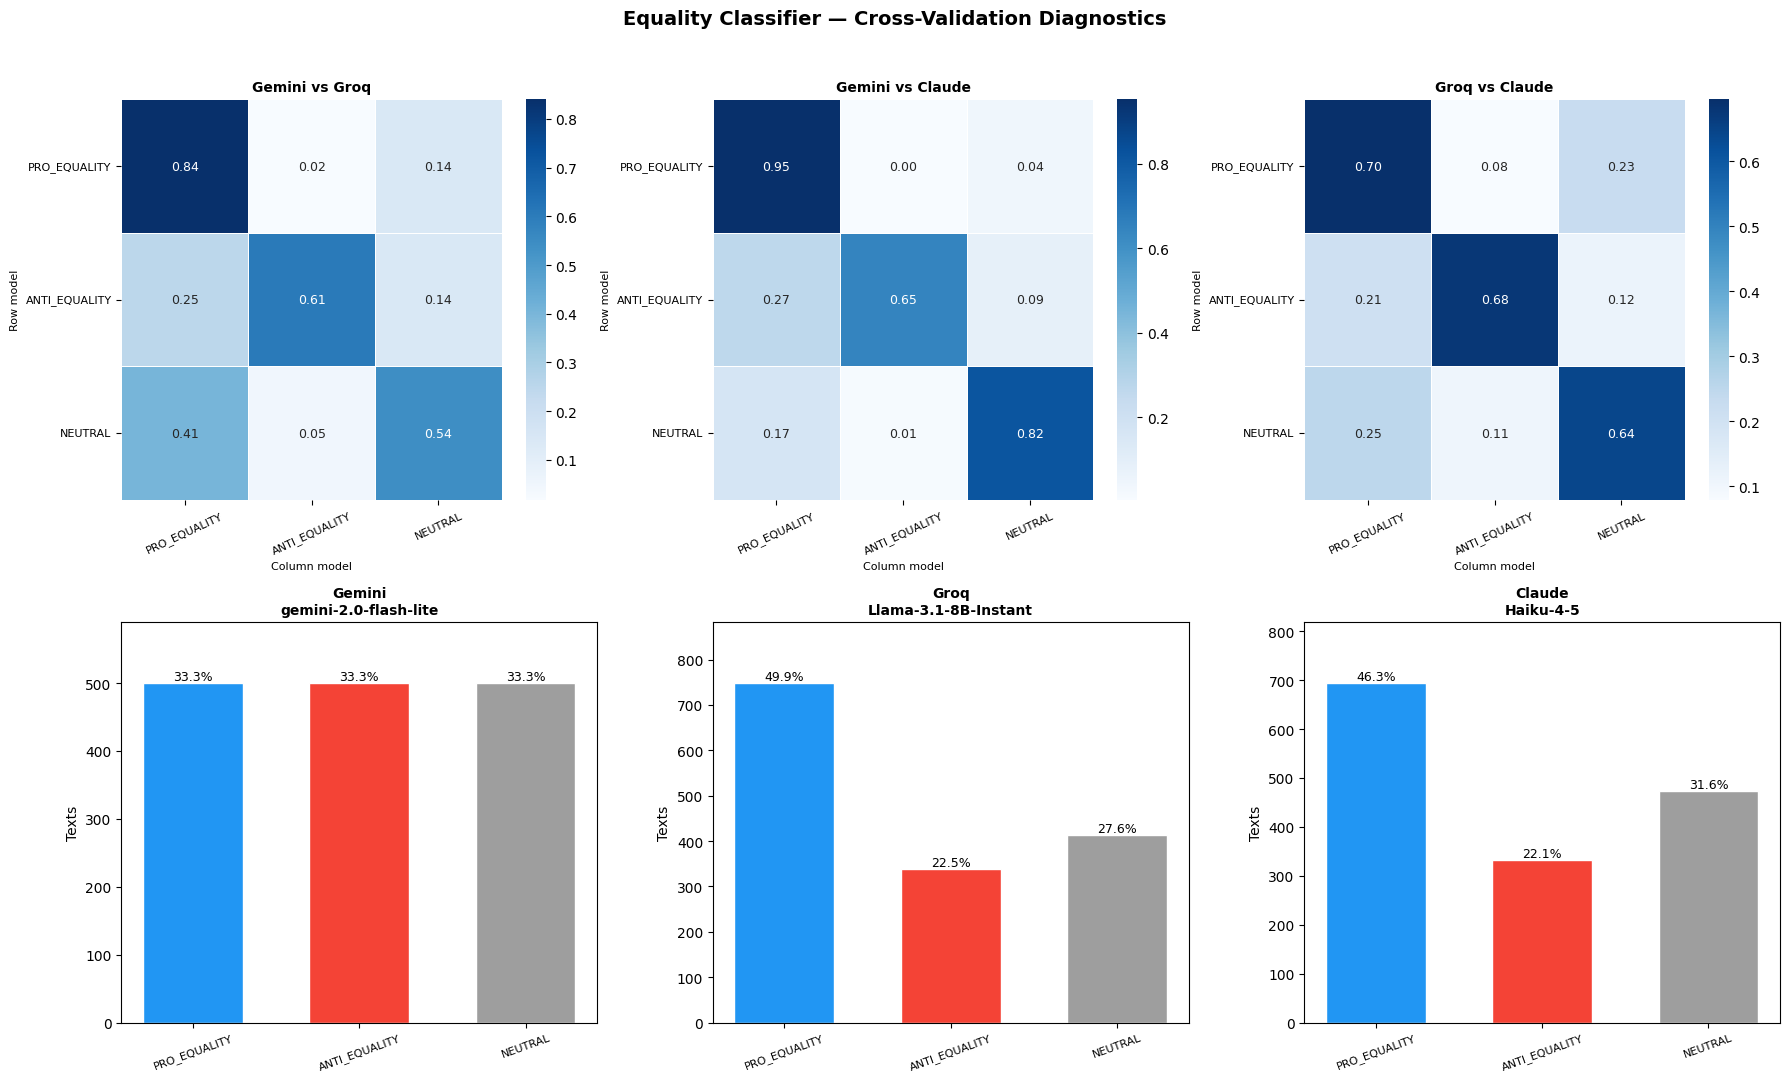

Figure saved to /content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/3. Narratives/All Dimensions/


In [ ]:
# ── Visualisation: confusion matrices + label distributions ──────────────
CAT_COLORS = {'PRO_EQUALITY': '#2196F3', 'ANTI_EQUALITY': '#F44336', 'NEUTRAL': '#9E9E9E'}
MODEL_LABELS = {
    'label_gemini': f'Gemini\n{GEMINI_MODEL}',
    'label_groq':   'Groq\nLlama-3.1-8B-Instant',
    'label_or':     'Claude\nHaiku-4-5',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Equality Classifier — Cross-Validation Diagnostics', fontsize=14, fontweight='bold')

# Row 0: confusion matrices (row model = reference, col model = comparison)
for ax, (c1, c2, title) in zip(axes[0], PAIRS):
    cm = confusion_matrix(cv[c1], cv[c2], labels=CATEGORIES, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=CATEGORIES, yticklabels=CATEGORIES,
                linewidths=0.5, annot_kws={'size': 9})
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Column model', fontsize=8)
    ax.set_ylabel('Row model', fontsize=8)
    ax.tick_params(axis='x', rotation=25, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

# Row 1: label distribution per model
for ax, col in zip(axes[1], ['label_gemini', 'label_groq', 'label_or']):
    counts = cv[col].value_counts().reindex(CATEGORIES, fill_value=0)
    bars = ax.bar(CATEGORIES, counts.values,
                  color=[CAT_COLORS[c] for c in CATEGORIES],
                  width=0.6, edgecolor='white')
    ax.bar_label(bars, labels=[f'{v/len(cv):.1%}' for v in counts.values], fontsize=9)
    ax.set_title(MODEL_LABELS[col], fontsize=10, fontweight='bold')
    ax.set_ylabel('Texts')
    ax.set_xticks(range(len(CATEGORIES)))
    ax.set_xticklabels(CATEGORIES, rotation=20, fontsize=8)
    ax.set_ylim(0, max(counts.values) * 1.18)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(CKPT_DIR + 'crossval_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to', CKPT_DIR)


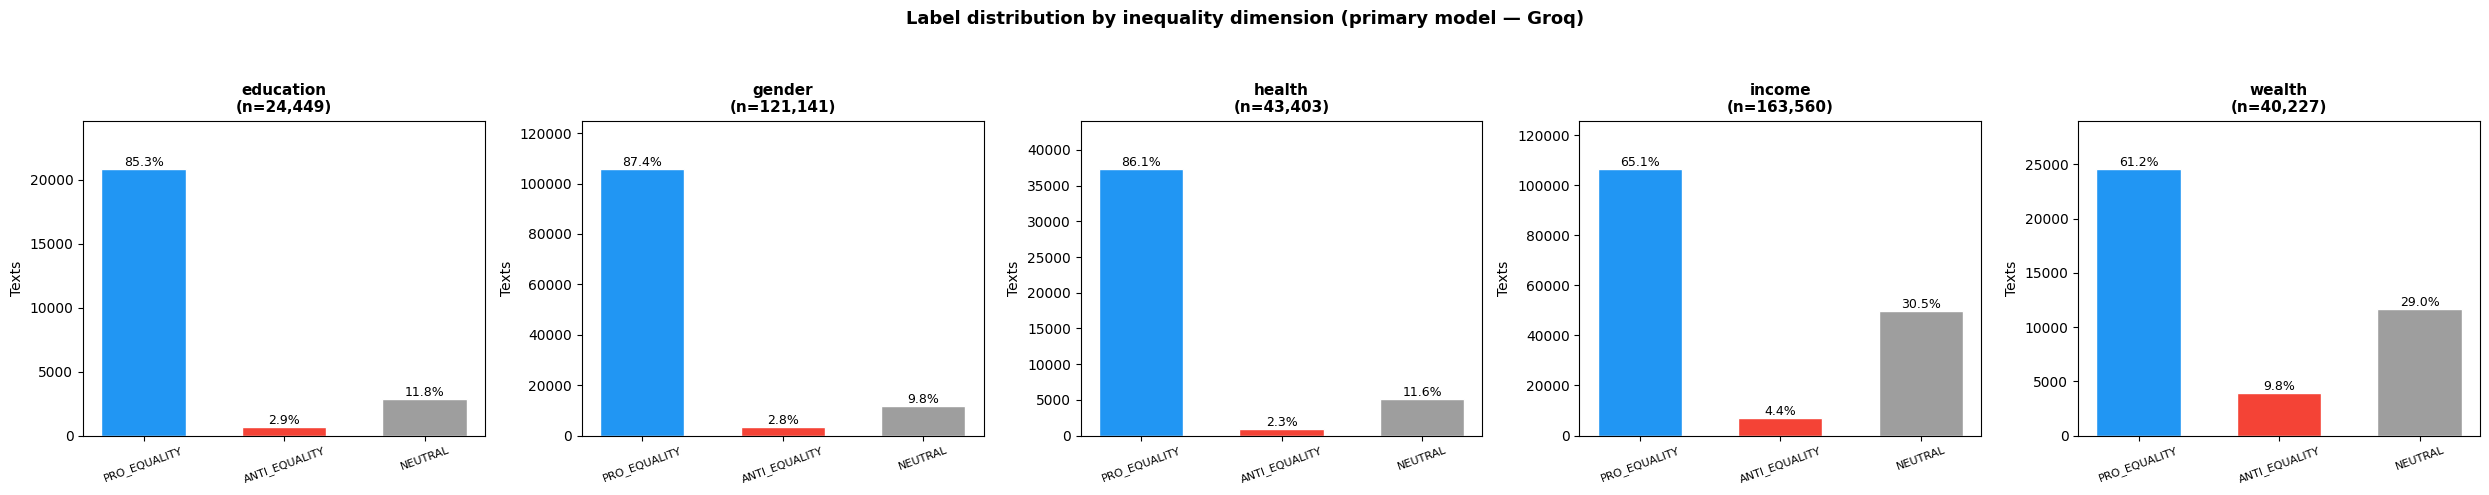

Saved label_by_dimension.png

Label counts by dimension:
label      PRO_EQUALITY  ANTI_EQUALITY  NEUTRAL   total  PRO_EQUALITY%  ANTI_EQUALITY%  NEUTRAL%
dimension                                                                                       
education         20858            701     2890   24449           85.3             2.9      11.8
gender           105883           3354    11904  121141           87.4             2.8       9.8
health            37366            984     5053   43403           86.1             2.3      11.6
income           106541           7146    49873  163560           65.1             4.4      30.5
wealth            24603           3944    11680   40227           61.2             9.8      29.0


In [ ]:
# ── Label distribution by dimension (primary model) ─────────────────────
# Merge primary labels with dimension info from df
results_dim = results.merge(df[['id', 'dimension']], on='id', how='left')

dims = sorted(results_dim['dimension'].dropna().unique())
n_dims = len(dims)
fig, axes = plt.subplots(1, n_dims, figsize=(5 * n_dims, 5), sharey=False)
if n_dims == 1: axes = [axes]
fig.suptitle('Label distribution by inequality dimension (primary model — Groq)',
              fontsize=13, fontweight='bold')

CAT_COLORS = {'PRO_EQUALITY': '#2196F3', 'ANTI_EQUALITY': '#F44336', 'NEUTRAL': '#9E9E9E'}

for ax, dim in zip(axes, dims):
    sub    = results_dim[results_dim['dimension'] == dim]
    counts = sub['label'].value_counts().reindex(CATEGORIES, fill_value=0)
    bars   = ax.bar(CATEGORIES, counts.values,
                    color=[CAT_COLORS[c] for c in CATEGORIES],
                    width=0.6, edgecolor='white')
    ax.bar_label(bars, labels=[f'{v/len(sub):.1%}' for v in counts.values], fontsize=9)
    ax.set_title(f'{dim}\n(n={len(sub):,})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Texts')
    ax.set_xticks(range(len(CATEGORIES)))
    ax.set_xticklabels(CATEGORIES, rotation=20, fontsize=8)
    ax.set_ylim(0, max(counts.values) * 1.18 if counts.max() > 0 else 10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(CKPT_DIR + 'label_by_dimension.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved label_by_dimension.png')

# Numeric breakdown table
print('\nLabel counts by dimension:')
pivot = (results_dim.groupby(['dimension', 'label'])
         .size().unstack(fill_value=0)
         .reindex(columns=CATEGORIES, fill_value=0))
pivot['total'] = pivot.sum(axis=1)
for c in CATEGORIES:
    pivot[c + '%'] = (pivot[c] / pivot['total'] * 100).round(1)
print(pivot.to_string())


In [ ]:
# ── Majority vote + disagreement analysis ────────────────────────────────
LABEL_COLS = ['label_groq', 'label_gemini', 'label_or']

def majority_vote(row):
    votes = [row[c] for c in LABEL_COLS]
    top, count = Counter(votes).most_common(1)[0]
    return pd.Series({'majority_label': top, 'consensus': count / 3})

cv[['majority_label', 'consensus']] = cv.apply(majority_vote, axis=1)

print('Majority-vote distribution:')
print(cv['majority_label'].value_counts().to_string())
print()
print(f'Full consensus (3/3):  {(cv["consensus"] == 1.0).mean():.1%}')
print(f'Majority (2+/3):       {(cv["consensus"] >= 2/3).mean():.1%}')
print()

# Disagreement deep-dive
discord = cv[cv['consensus'] < 1.0][LABEL_COLS + ['majority_label']]
print(f'Texts with any disagreement: {len(discord)} ({len(discord)/len(cv):.1%})')

# Most common disagreement patterns
discord['pattern'] = discord.apply(
    lambda r: tuple(sorted([r[c] for c in LABEL_COLS])), axis=1)
print('\nTop disagreement patterns:')
print(discord['pattern'].value_counts().head(10).to_string())


Majority-vote distribution:
majority_label
PRO_EQUALITY     622
NEUTRAL          471
ANTI_EQUALITY    407

Full consensus (3/3):  58.5%
Majority (2+/3):       97.7%

Texts with any disagreement: 623 (41.5%)

Top disagreement patterns:
pattern
(NEUTRAL, NEUTRAL, PRO_EQUALITY)                169
(NEUTRAL, PRO_EQUALITY, PRO_EQUALITY)           141
(ANTI_EQUALITY, ANTI_EQUALITY, PRO_EQUALITY)    116
(ANTI_EQUALITY, PRO_EQUALITY, PRO_EQUALITY)      66
(ANTI_EQUALITY, ANTI_EQUALITY, NEUTRAL)          60
(ANTI_EQUALITY, NEUTRAL, NEUTRAL)                37
(ANTI_EQUALITY, NEUTRAL, PRO_EQUALITY)           34


In [ ]:
# ── Final export ─────────────────────────────────────────────────────────
# Save updated cross-val with majority vote
cv.to_parquet(CROSSVAL_PATH, index=False)

# Primary results — join dimension + country metadata back in
final = (pd.read_parquet(PRIMARY_CKPT)
         .rename(columns={'label': 'label_primary', 'conf': 'conf_primary'})
         .merge(df[['id', 'dimension', 'country']], on='id', how='left'))
final.to_parquet(FINAL_PATH, index=False)

print(f'Primary results:  {len(final):,} texts  →  {FINAL_PATH}')
print(f'Cross-val sample: {len(cv):,} texts  →  {CROSSVAL_PATH}')
print()

# Summary by dimension
print('Label distribution by dimension (primary model):')
pivot = (final.groupby(['dimension', 'label_primary'])
         .size().unstack(fill_value=0)
         .reindex(columns=CATEGORIES, fill_value=0))
pivot['total'] = pivot.sum(axis=1)
for c in CATEGORIES:
    pivot[c + '%'] = (pivot[c] / pivot['total'] * 100).round(1)
print(pivot.to_string())
print()

# Country check
print('Country distribution:', final['country'].value_counts().to_dict())

# Model summary table
summary = pd.DataFrame({
    'Model': [f'Gemini {GEMINI_MODEL} (primary)', 'Groq Llama-3.1-8B-Instant', 'Claude Haiku-4-5'],
    'Texts': [len(final), len(df_groq), len(df_or)],
    'PRO_EQ%':  [final['label_primary'].eq('PRO_EQUALITY').mean(),
                 df_groq['label_groq'].eq('PRO_EQUALITY').mean(),
                 df_or['label_or'].eq('PRO_EQUALITY').mean()],
    'ANTI_EQ%': [final['label_primary'].eq('ANTI_EQUALITY').mean(),
                 df_groq['label_groq'].eq('ANTI_EQUALITY').mean(),
                 df_or['label_or'].eq('ANTI_EQUALITY').mean()],
    'NEUTRAL%': [final['label_primary'].eq('NEUTRAL').mean(),
                 df_groq['label_groq'].eq('NEUTRAL').mean(),
                 df_or['label_or'].eq('NEUTRAL').mean()],
})
print(summary.to_string(index=False))


Primary results:  392,780 texts  →  /content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/3. Narratives/All Dimensions/results_final.parquet
Cross-val sample: 1,500 texts  →  /content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/3. Narratives/All Dimensions/crossval.parquet

Label distribution by dimension (primary model):
label_primary  PRO_EQUALITY  ANTI_EQUALITY  NEUTRAL   total  PRO_EQUALITY%  ANTI_EQUALITY%  NEUTRAL%
dimension                                                                                           
education             20858            701     2890   24449           85.3             2.9      11.8
gender               105883           3354    11904  121141           87.4             2.8       9.8
health                37366            984     5053   43403           86.1             2.3      11.6
income               106541           7146    49873  163560           65.1             4.4      30.5
wealth                24603           3944    11680   40227           61.

In [ ]:
# ── Manual classification export — 50 por categoría × dimensión ──────────
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.worksheet.datavalidation import DataValidation

N_PER_STRATUM = 50
SEED = 42

# Estratificado por dimension × label_primary
primary_labels = pd.read_parquet(PRIMARY_CKPT)[['id', 'label']].rename(columns={'label': 'label_primary'})
df_labeled = df.merge(primary_labels, on='id', how='inner')

sample_manual = (df_labeled
    .groupby(['dimension', 'label_primary'], group_keys=False)
    .apply(lambda g: g.sample(min(N_PER_STRATUM, len(g)), random_state=SEED))
    .reset_index(drop=True)
    [['id', 'dimension', 'country', 'text', 'label_primary']]
    .copy())

sample_manual['label_manual'] = ''
sample_manual['notes']        = ''
sample_manual = sample_manual.sort_values(['dimension', 'label_primary']).reset_index(drop=True)

counts = sample_manual.groupby(['dimension', 'label_primary']).size().unstack(fill_value=0)
print(counts)
print(f'\nTotal: {len(sample_manual):,} textos')

# ── Workbook ──────────────────────────────────────────────────────────────
wb = openpyxl.Workbook()
ws = wb.active
ws.title = 'Manual Classification'

HDR_FILL  = PatternFill('solid', fgColor='1565C0')
ALT_FILL  = PatternFill('solid', fgColor='E3F2FD')
WHT_FILL  = PatternFill('solid', fgColor='FFFFFF')
PRO_FILL  = PatternFill('solid', fgColor='BBDEFB')
ANTI_FILL = PatternFill('solid', fgColor='FFCDD2')
NEUT_FILL = PatternFill('solid', fgColor='F5F5F5')
LABEL_COLOR = {'PRO_EQUALITY': PRO_FILL, 'ANTI_EQUALITY': ANTI_FILL, 'NEUTRAL': NEUT_FILL}

thin   = Side(style='thin', color='BDBDBD')
border = Border(left=thin, right=thin, top=thin, bottom=thin)

HEADERS = ['#', 'ID', 'Dimension', 'Country', 'Text', 'Label Primary', 'Label Manual', 'Notes']
COL_W   = [5,   12,   14,          10,        80,     16,              16,              30]

# Header
for col_i, (h, w) in enumerate(zip(HEADERS, COL_W), start=1):
    cell = ws.cell(row=1, column=col_i, value=h)
    cell.fill      = HDR_FILL
    cell.font      = Font(bold=True, color='FFFFFF', size=11)
    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    cell.border    = border
    ws.column_dimensions[get_column_letter(col_i)].width = w
ws.row_dimensions[1].height = 22

# Dropdown en columna G (Label Manual)
dv = DataValidation(type='list',
                    formula1='"PRO_EQUALITY,ANTI_EQUALITY,NEUTRAL"',
                    allow_blank=True,
                    showDropDown=False)
ws.add_data_validation(dv)

MANUAL_COL = 7  # G

for row_i, row in sample_manual.iterrows():
    r = row_i + 2
    values = [r-1, row['id'], row['dimension'], row['country'],
              row['text'], row['label_primary'], '', '']
    base_fill = ALT_FILL if row_i % 2 == 0 else WHT_FILL

    for col_i, val in enumerate(values, start=1):
        cell = ws.cell(row=r, column=col_i, value=val)
        cell.border    = border
        cell.alignment = Alignment(
            vertical='top',
            wrap_text=(col_i in (5, 8)),
            horizontal='left' if col_i == 5 else 'center'
        )
        # Columna Label Primary: color por categoría
        if col_i == 6:
            cell.fill = LABEL_COLOR.get(row['label_primary'], base_fill)
            cell.font = Font(bold=True, size=9)
        else:
            cell.fill = base_fill

    dv.add(ws.cell(row=r, column=MANUAL_COL))
    ws.row_dimensions[r].height = 60

ws.freeze_panes = 'A2'

# ── Hoja Instructions ─────────────────────────────────────────────────────
ws2 = wb.create_sheet('Instructions')
instructions = [
    ['Label',          'Meaning',                                           'Example'],
    ['PRO_EQUALITY',   'Supports reducing inequality / promoting equity',   '"We must raise taxes on the wealthy"'],
    ['ANTI_EQUALITY',  'Opposes redistribution or equity measures',         '"Wealth taxes kill investment"'],
    ['NEUTRAL',        'Descriptive, factual, no clear stance',             '"Income inequality rose 3% last year"'],
    ['', '', ''],
    ['NOTE:',          'Label Primary = model prediction (for reference).', ''],
    ['Tip:',           'If unsure between PRO and NEUTRAL → choose NEUTRAL.',''],
    ['Tip:',           'Use Notes to flag ambiguous or borderline cases.',   ''],
]
for r_i, row_vals in enumerate(instructions, start=1):
    for c_i, v in enumerate(row_vals, start=1):
        cell = ws2.cell(row=r_i, column=c_i, value=v)
        cell.alignment = Alignment(wrap_text=True, vertical='top')
        if r_i == 1:
            cell.fill = HDR_FILL
            cell.font = Font(bold=True, color='FFFFFF')
        elif r_i in (2, 3, 4) and c_i == 1:
            cell.fill = list(LABEL_COLOR.values())[r_i - 2]
            cell.font = Font(bold=True, size=9)

for c_i, w in zip([1, 2, 3], [16, 50, 45]):
    ws2.column_dimensions[get_column_letter(c_i)].width = w

# ── Hoja Summary ──────────────────────────────────────────────────────────
ws3 = wb.create_sheet('Summary')
ws3.cell(row=1, column=1, value='Stratum counts (dimension × label_primary)')
ws3.cell(row=1, column=1).font = Font(bold=True)
summary_df = counts.reset_index()
cols = list(summary_df.columns)
for c_i, col in enumerate(cols, start=1):
    ws3.cell(row=2, column=c_i, value=col).font = Font(bold=True)
for r_i, row in summary_df.iterrows():
    for c_i, val in enumerate(row, start=1):
        ws3.cell(row=r_i+3, column=c_i, value=val)

# ── Guardar ───────────────────────────────────────────────────────────────
MANUAL_PATH = CKPT_DIR + 'manual_classification.xlsx'
wb.save(MANUAL_PATH)
print(f'\nGuardado: {MANUAL_PATH}')
print(f'Textos: {len(sample_manual):,}  (target: {5*3*N_PER_STRATUM})')


label_primary  ANTI_EQUALITY  NEUTRAL  PRO_EQUALITY
dimension                                          
education                 50       50            50
gender                    50       50            50
health                    50       50            50
income                    50       50            50
wealth                    50       50            50

Total: 750 textos

Guardado: /content/drive/MyDrive/RA/RA/NOW/DataProcesing/LLMs/3. Narratives/All Dimensions/manual_classification.xlsx
Textos: 750  (target: 750)
